## Functional API Classification

In [3]:
import tensorflow as tf
from tensorflow import keras

# Data
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 784).astype("float32") / 255.0

## Model



In [4]:
inputs=keras.Input(shape=(784, ))
x=keras.layers.Dense(256, activation="relu")(inputs)
x=keras.layers.Dropout(0.3)(x)
x=keras.layers.Dense(128, activation="relu")(x)
x=keras.layers.Dropout(0.3)(x)
outputs=keras.layers.Dense(10, activation="softmax")(x)

model=keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
## Train
history=model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8754 - loss: 0.4098 - val_accuracy: 0.9637 - val_loss: 0.1283
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9464 - loss: 0.1779 - val_accuracy: 0.9737 - val_loss: 0.0880
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9605 - loss: 0.1324 - val_accuracy: 0.9767 - val_loss: 0.0771
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9672 - loss: 0.1051 - val_accuracy: 0.9762 - val_loss: 0.0756
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9710 - loss: 0.0934 - val_accuracy: 0.9798 - val_loss: 0.0693
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9747 - loss: 0.0799 - val_accuracy: 0.9818 - val_loss: 0.0638
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0704 - val_accuracy: 0.9803 - val_loss: 0.0619
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9797 - loss: 0.0650 - val_accuracy: 0.

In [7]:
## Evaulate
from sklearn.metrics import f1_score, precision_score, recall_score

loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("Classification Report:")
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
print(f"Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"Test accuracy: {acc:.4f}")

Classification Report:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
Precision: 0.9809
Recall: 0.9809
F1 Score: 0.9809
Test accuracy: 0.9809


Confusion Matrix:
[[ 971    1    0    1    0    0    1    1    4    1]
 [   0 1131    1    0    0    0    0    0    3    0]
 [   4    2 1004    5    1    0    2    8    6    0]
 [   0    0    4  990    0    9    0    3    2    2]
 [   1    1    3    0  958    0    4    3    1   11]
 [   2    0    0    5    1  873    3    1    4    3]
 [   4    2    2    1    3    4  941    0    1    0]
 [   0    2    6    2    0    0    0 1008    1    9]
 [   3    1    2    3    1    7    3    4  945    5]
 [   1    2    0    5    5    7    0    1    0  988]]


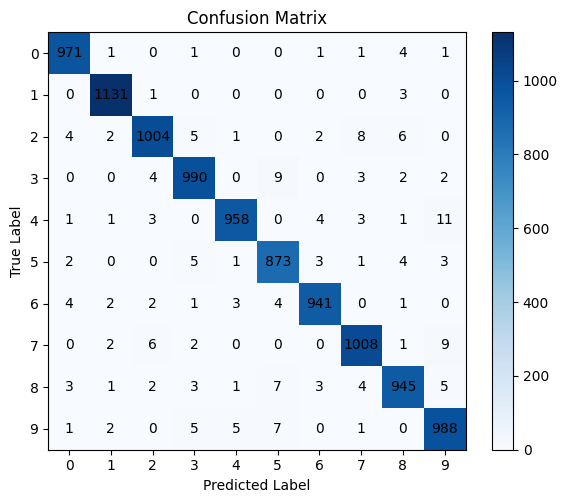

In [8]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = np.unique(y_test)
plt.xticks(classes)
plt.yticks(classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center')

plt.tight_layout()
plt.show()